# Degradation Function Test
Visual check of all four degradation methods across different intensity levels on a single IAM image.

In [8]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import sys

sys.path.append("../../src")

from degradation import (
    apply_awgn,
    apply_gaussian_blur,
    apply_jpeg_compression,
    apply_downscaling,
)

Label: Become a success with a disc and hey presto ! You 're a star ... . Rolly sings with


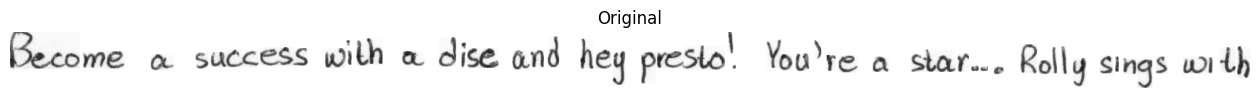

In [9]:
# Load one image from HF parquet
dataset = load_dataset("LeMerta/bachelor-thesis-datasets", data_dir="iam/raw")
sample = dataset["test"][0]
image = sample["image"].convert("RGB")
label = sample["text"]

print(f"Label: {label}")
plt.figure(figsize=(16, 2))
plt.imshow(image)
plt.title("Original")
plt.axis("off")
plt.show()

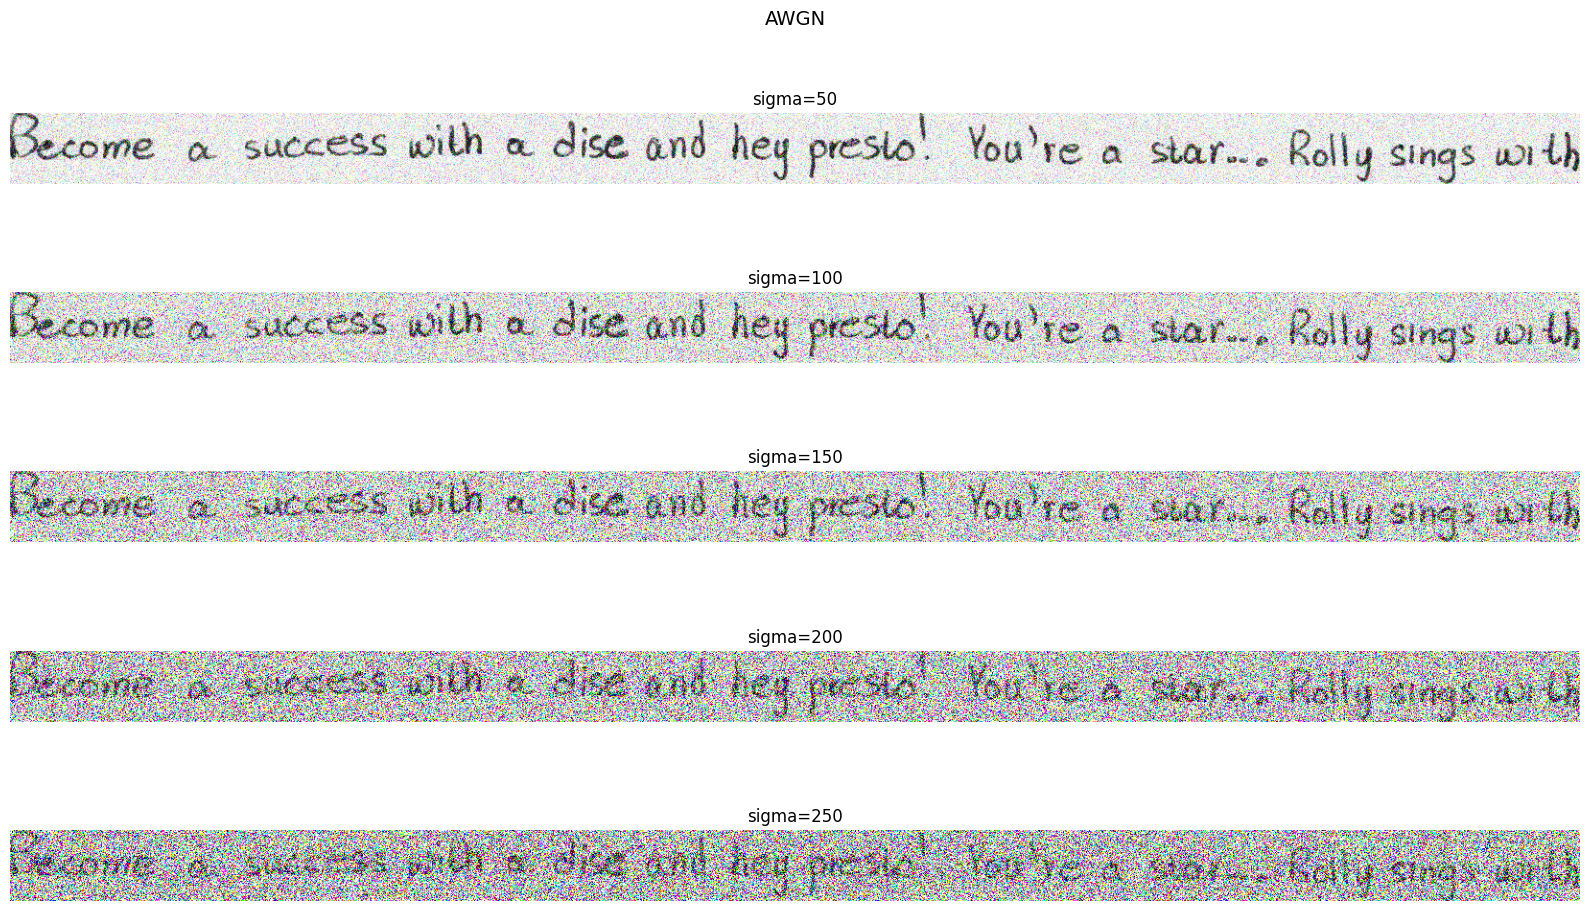

In [10]:
# AWGN
awgn_sigmas = [50, 100, 150, 200, 250]

fig, axes = plt.subplots(5, 1, figsize=(16, 10))
fig.suptitle("AWGN", fontsize=14)
for ax, sigma in zip(axes, awgn_sigmas):
    ax.imshow(apply_awgn(image, sigma=sigma), cmap="gray")
    ax.set_title(f"sigma={sigma}")
    ax.axis("off")
plt.tight_layout()
plt.show()

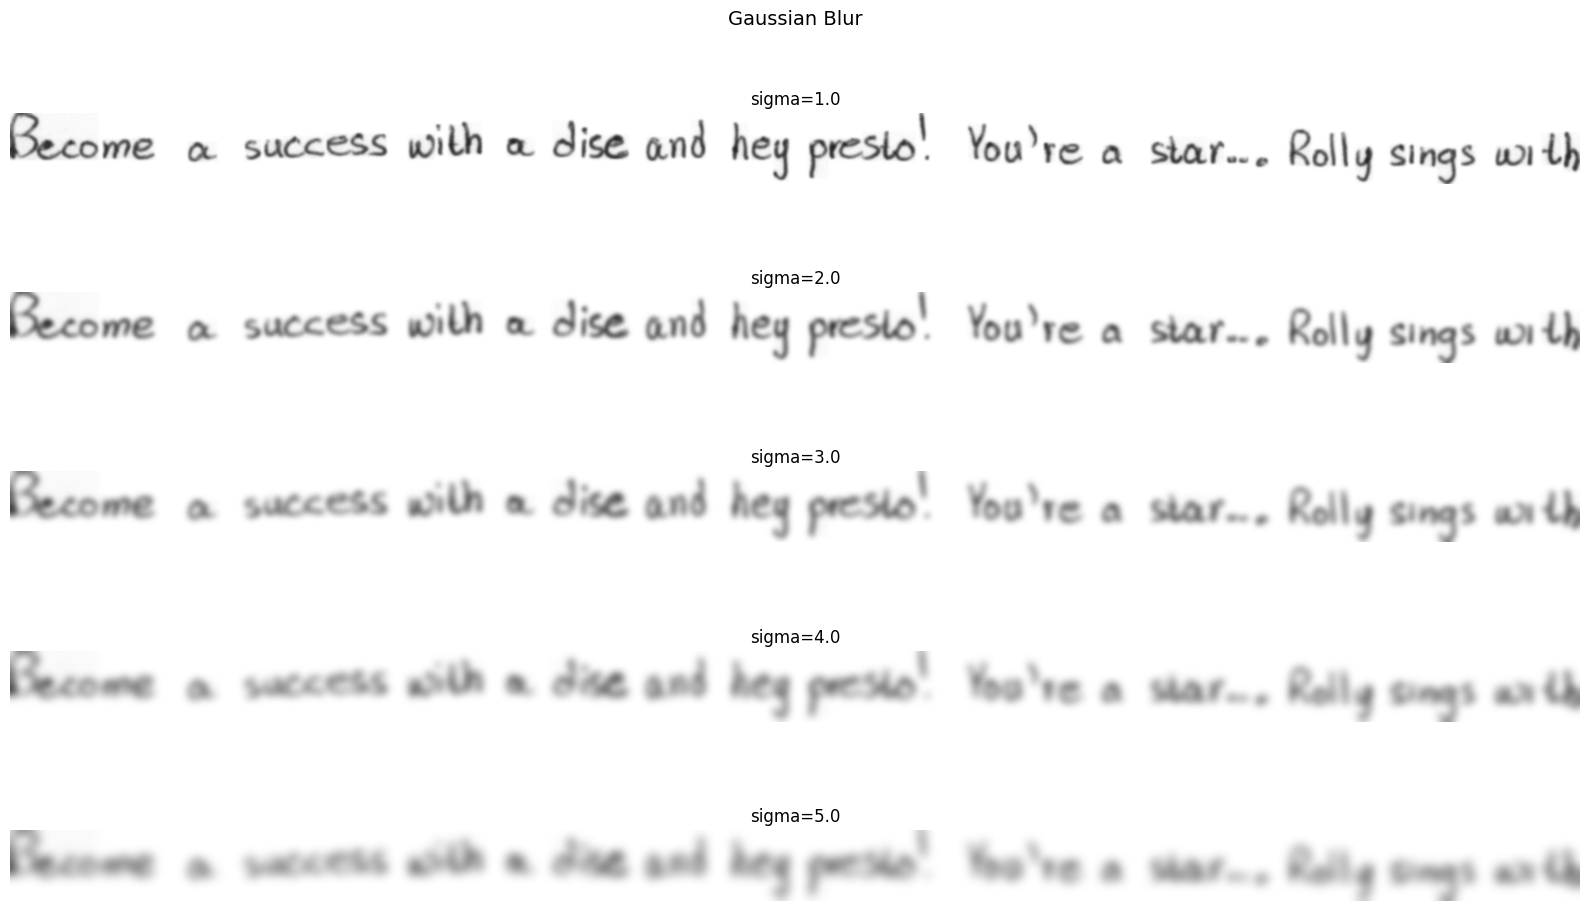

In [11]:
# Gaussian blur
blur_sigmas = [1.0, 2.0, 3.0, 4.0, 5.0]

fig, axes = plt.subplots(5, 1, figsize=(16, 10))
fig.suptitle("Gaussian Blur", fontsize=14)
for ax, sigma in zip(axes, blur_sigmas):
    ax.imshow(apply_gaussian_blur(image, sigma=sigma), cmap="gray")
    ax.set_title(f"sigma={sigma}")
    ax.axis("off")
plt.tight_layout()
plt.show()

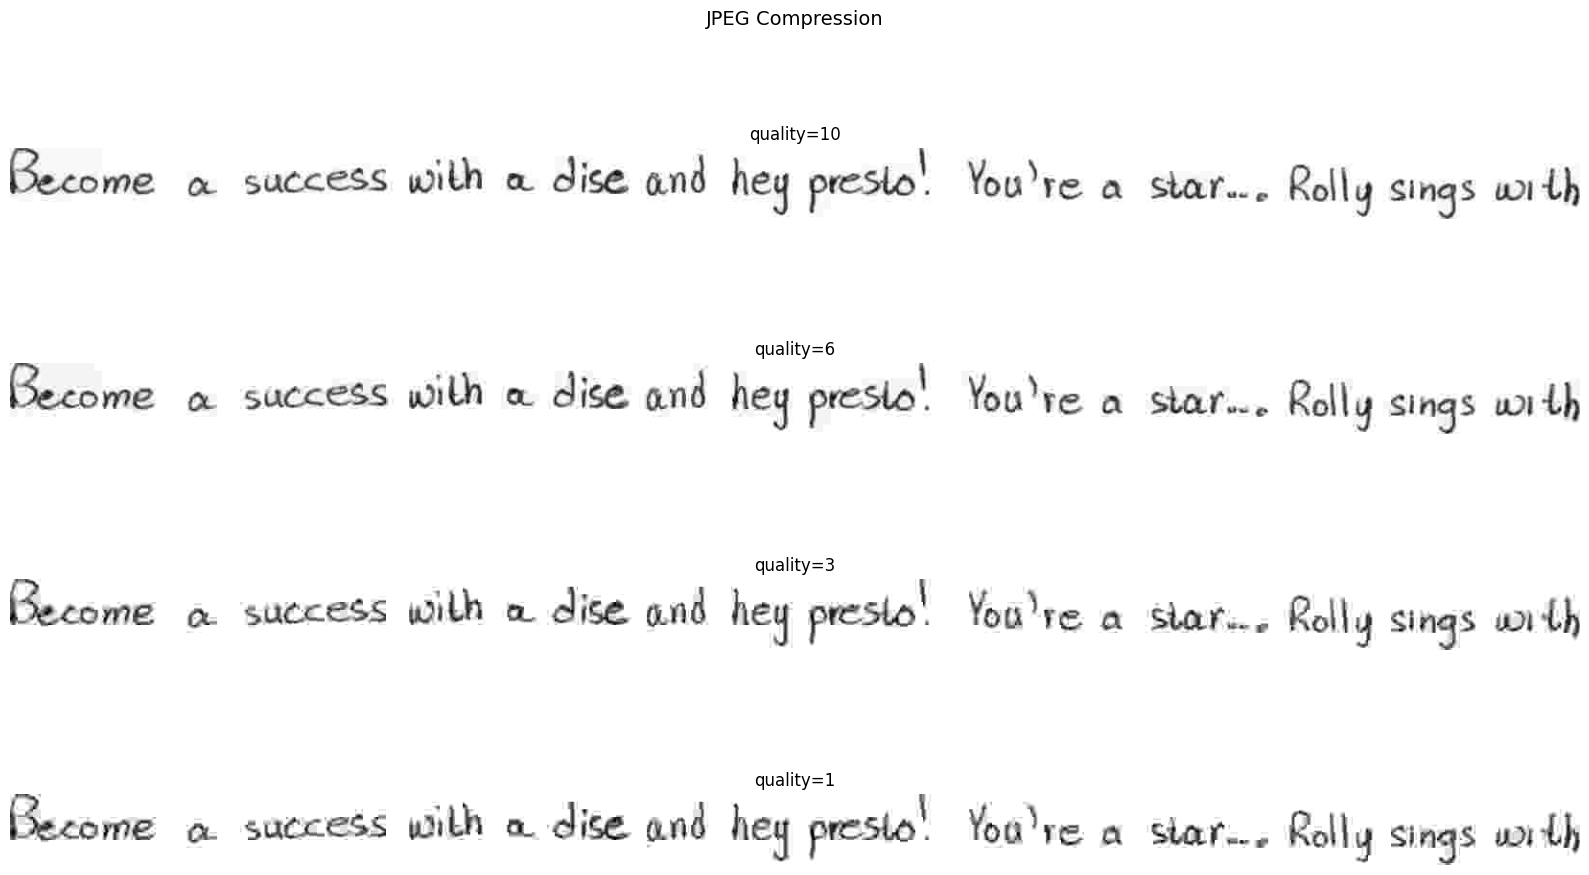

In [12]:
# JPEG compression
jpeg_qualities = [10,6,3,1]

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
fig.suptitle("JPEG Compression", fontsize=14)
for ax, quality in zip(axes, jpeg_qualities):
    ax.imshow(apply_jpeg_compression(image, quality=quality), cmap="gray")
    ax.set_title(f"quality={quality}")
    ax.axis("off")
plt.tight_layout()
plt.show()

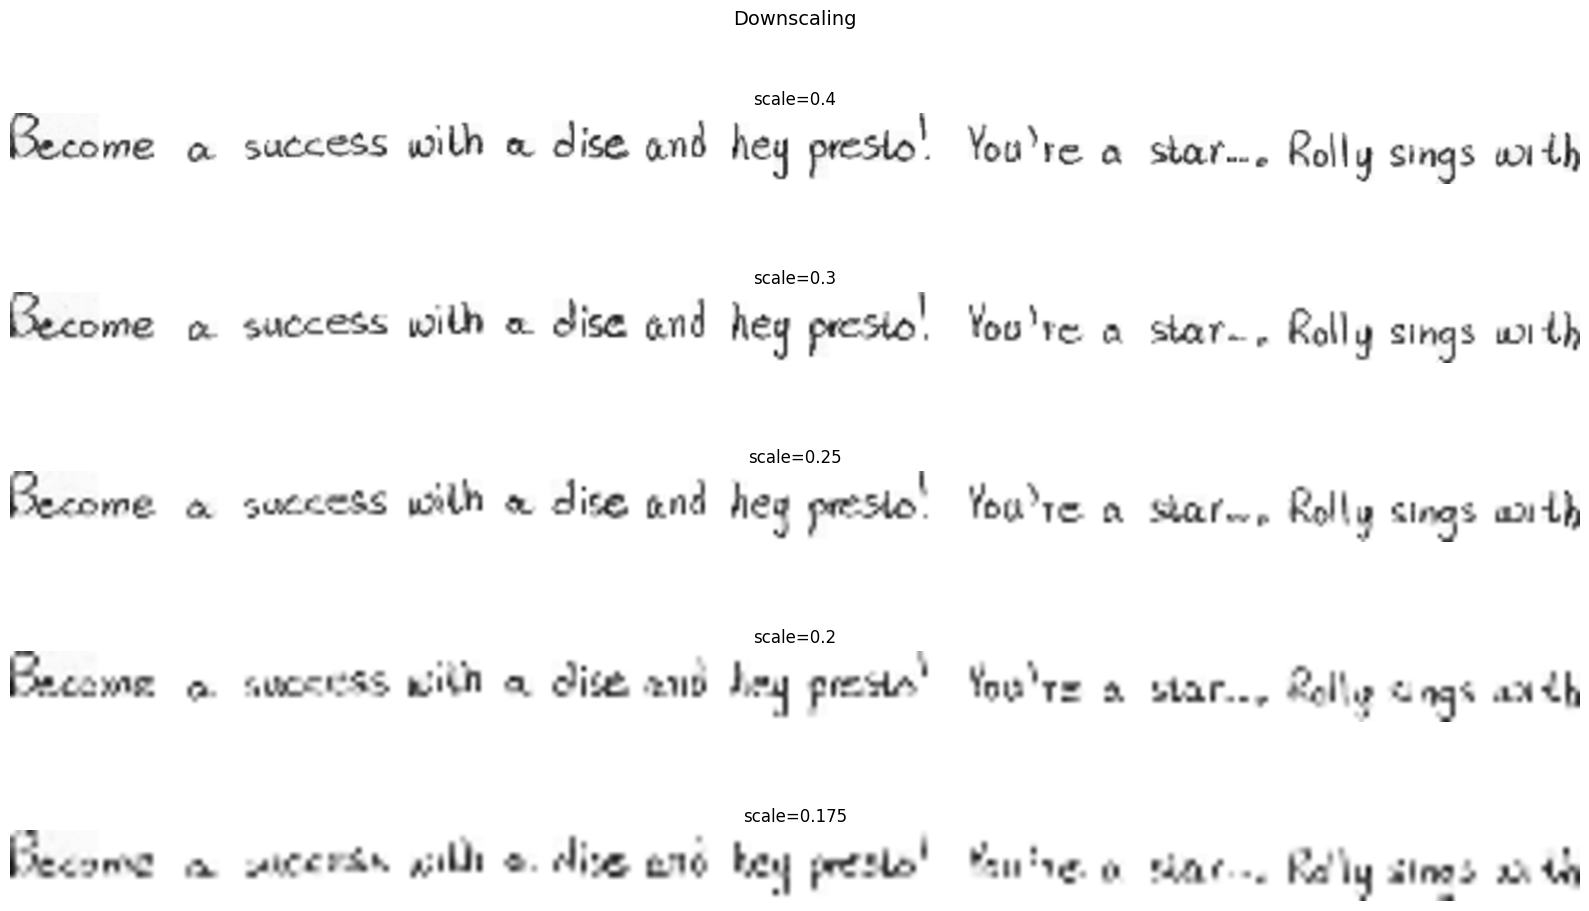

In [13]:
# Downscaling
scale_factors = [0.4, 0.3, 0.25, 0.2, 0.175]

fig, axes = plt.subplots(5, 1, figsize=(16, 10))
fig.suptitle("Downscaling", fontsize=14)
for ax, factor in zip(axes, scale_factors):
    ax.imshow(apply_downscaling(image, scale_factor=factor), cmap="gray")
    ax.set_title(f"scale={factor}")
    ax.axis("off")
plt.tight_layout()
plt.show()